# Project 1 — Supermarket Sales EDA

## Project Overview
This project performs exploratory data analysis (EDA) on a supermarket sales dataset.

The analysis focuses on:
- Data quality and cleaning
- Product-line sales performance
- City and branch performance
- Customer type and gender
- Payment methods
- Quantity and sales relationships
- Date-based sales patterns

The goal is to practice turning raw transactional data into useful business insights using Pandas and visualization.


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


## Load the Dataset

The dataset is loaded into a Pandas DataFrame so that we can inspect its structure, quality, and contents before starting the analysis.


In [3]:
df = pd.read_csv('supermarket_sales_eda_training.csv')

## 1. Understand the Dataset

First, we check the number of rows and columns and inspect the data types.

This helps identify which columns are numerical, categorical, and date-related.


In [4]:
df.shape
df.dtypes

,0
Invoice_ID,object
Date,object
Branch,object
City,object
Customer_type,object
Gender,object
Product_line,object
Unit_price,float64
Quantity,int64
Total,float64


In [5]:
df.columns

Index(['Invoice_ID', 'Date', 'Branch', 'City', 'Customer_type', 'Gender',
       'Product_line', 'Unit_price', 'Quantity', 'Total', 'Payment'],
      dtype='object')

## 2. Check Missing Values

We check every column for missing values.

Missing values need to be identified before analysis because they can affect calculations and grouping results.


In [6]:
df.isna().sum()

,0
Invoice_ID,0
Date,0
Branch,0
City,0
Customer_type,0
Gender,8
Product_line,0
Unit_price,8
Quantity,0
Total,0


## 3. Check for Duplicate Records

Duplicate transactions can distort sales totals and counts, so we check for exact duplicate rows before proceeding.


In [7]:
df.duplicated().sum()

np.int64(8)

## 4. Convert the Date Column

The `Date` column is converted from text to `datetime`.

This is necessary for reliable date-based analysis, such as grouping sales by day or month.


In [8]:
df['Date'] = pd.to_datetime(df['Date'])

In [9]:
df.dtypes

,0
Invoice_ID,object
Date,datetime64[ns]
Branch,object
City,object
Customer_type,object
Gender,object
Product_line,object
Unit_price,float64
Quantity,int64
Total,float64


## Missing-Value Percentage

Calculating the percentage of missing values gives better context than the raw count alone.

Here, `Gender`, `Unit_price`, and `Payment` each have 8 missing values, representing about 1.32% of the dataset.


In [10]:

(df.isna().sum()/ len(df))*100

,0
Invoice_ID,0.000000
Date,0.000000
Branch,0.000000
City,0.000000
Customer_type,0.000000
Gender,1.315789
Product_line,0.000000
Unit_price,1.315789
Quantity,0.000000
Total,0.000000


## Inspect the Data

We preview the first few rows to understand how the transactions are structured.


In [11]:
df.head()

,Invoice_ID,Date,Branch,City,Customer_type,Gender,Product_line,Unit_price,Quantity,Total,Payment
0,INV-10110,2026-03-08,A,Bhopal,Normal,Female,Health and beauty,98.38,5,491.90,Ewallet
1,INV-10011,2026-02-16,A,Bhopal,Normal,Female,Health and beauty,29.84,2,59.68,Cash
2,INV-10185,2026-03-06,A,Bhopal,Member,Female,Home and lifestyle,17.59,2,35.18,Credit card
3,INV-10078,2026-01-09,A,Bhopal,Member,Female,Electronic accessories,89.14,8,713.12,Cash
4,INV-10539,2026-03-12,B,Indore,Normal,Male,Fashion accessories,66.85,5,334.25,Ewallet


## Inspect Duplicate Rows

The dataset contains 8 exact duplicate rows.

These duplicates are investigated before being removed.


In [12]:
df[df.duplicated()]

,Invoice_ID,Date,Branch,City,Customer_type,Gender,Product_line,Unit_price,Quantity,Total,Payment
153,INV-10133,2026-01-23,A,Bhopal,Normal,Male,Food and beverages,64.49,9,580.41,Cash
190,INV-10262,2026-01-18,C,Jabalpur,Normal,Male,Sports and travel,84.38,6,506.28,Cash
204,INV-10317,2026-02-03,B,Indore,Normal,Male,Health and beauty,31.94,7,223.58,Ewallet
284,INV-10440,2026-03-17,A,Bhopal,Member,Female,Sports and travel,22.03,1,22.03,Credit card
537,INV-10338,2026-03-28,C,Jabalpur,Normal,Female,Health and beauty,49.52,6,297.12,Ewallet
542,INV-10581,2026-02-23,B,Indore,Normal,Female,Electronic accessories,71.51,7,500.57,Ewallet
557,INV-10455,2026-03-21,A,Bhopal,Normal,Female,Electronic accessories,84.14,1,84.14,Credit card
568,INV-10576,2026-02-22,C,Jabalpur,Normal,Female,Food and beverages,32.17,5,160.85,Credit card


In [13]:
df[df.duplicated(keep=False)].sort_values(by='Invoice_ID')

,Invoice_ID,Date,Branch,City,Customer_type,Gender,Product_line,Unit_price,Quantity,Total,Payment
61,INV-10133,2026-01-23,A,Bhopal,Normal,Male,Food and beverages,64.49,9,580.41,Cash
153,INV-10133,2026-01-23,A,Bhopal,Normal,Male,Food and beverages,64.49,9,580.41,Cash
45,INV-10262,2026-01-18,C,Jabalpur,Normal,Male,Sports and travel,84.38,6,506.28,Cash
190,INV-10262,2026-01-18,C,Jabalpur,Normal,Male,Sports and travel,84.38,6,506.28,Cash
29,INV-10317,2026-02-03,B,Indore,Normal,Male,Health and beauty,31.94,7,223.58,Ewallet
204,INV-10317,2026-02-03,B,Indore,Normal,Male,Health and beauty,31.94,7,223.58,Ewallet
60,INV-10338,2026-03-28,C,Jabalpur,Normal,Female,Health and beauty,49.52,6,297.12,Ewallet
537,INV-10338,2026-03-28,C,Jabalpur,Normal,Female,Health and beauty,49.52,6,297.12,Ewallet
185,INV-10440,2026-03-17,A,Bhopal,Member,Female,Sports and travel,22.03,1,22.03,Credit card
284,INV-10440,2026-03-17,A,Bhopal,Member,Female,Sports and travel,22.03,1,22.03,Credit card


## Remove Duplicates

The 8 duplicate records are removed using `drop_duplicates()`.

After cleaning, the dataset contains 600 unique transactions.


In [14]:
df.drop_duplicates(inplace=True)

In [15]:
df.duplicated().sum()

np.int64(0)

## 5. Descriptive Statistics

`describe()` gives a statistical overview of the numerical columns.

Important observations:
- Quantity ranges from 1 to 50.
- Total sales per transaction range from 11.20 to 3,119.50.
- The mean transaction total is about 280.94.
- Quantity has a relatively large maximum of 50 compared with the median of 4, indicating that some transactions have unusually high quantities.


In [16]:
df.describe()

,Date,Unit_price,Quantity,Total
count,600,592.00000,600.000000,600.000000
mean,2026-02-14 14:12:00,56.44951,4.911667,280.936683
min,2026-01-01 00:00:00,10.18000,1.000000,11.200000
25%,2026-01-24 00:00:00,36.69000,3.000000,111.230000
50%,2026-02-15 00:00:00,57.45500,4.000000,228.535000
75%,2026-03-08 00:00:00,77.82500,6.250000,393.615000
max,2026-03-31 00:00:00,99.96000,50.000000,3119.500000
std,NaN,25.21117,3.797090,258.671404


## Investigate High-Quantity Transactions

Rather than automatically deleting unusual values, we inspect transactions with quantity above 10.

There are 5 such transactions. These values are worth investigating because they are much higher than the typical quantity, but they are not automatically errors.


In [17]:
df[df['Quantity'] > 10]

,Invoice_ID,Date,Branch,City,Customer_type,Gender,Product_line,Unit_price,Quantity,Total,Payment
30,INV-10303,2026-03-31,B,Indore,Member,NaN,Food and beverages,81.05,25,2026.25,Credit card
77,INV-10312,2026-01-27,A,Bhopal,Normal,Male,Food and beverages,62.39,50,3119.50,Ewallet
319,INV-10104,2026-03-31,B,Indore,Member,Female,Sports and travel,17.55,35,614.25,Ewallet
347,INV-10151,2026-03-04,C,Jabalpur,Normal,Female,Fashion accessories,43.59,30,1307.70,Cash
580,INV-10561,2026-02-09,C,Jabalpur,Normal,Female,Electronic accessories,67.51,40,2700.40,Credit card


## Investigate High-Value Transactions

We inspect transactions with totals above 1,000.

This helps determine whether unusually large sales are associated with the high-quantity transactions.


In [18]:
df[df['Total']>1000]

,Invoice_ID,Date,Branch,City,Customer_type,Gender,Product_line,Unit_price,Quantity,Total,Payment
30,INV-10303,2026-03-31,B,Indore,Member,NaN,Food and beverages,81.05,25,2026.25,Credit card
77,INV-10312,2026-01-27,A,Bhopal,Normal,Male,Food and beverages,62.39,50,3119.50,Ewallet
347,INV-10151,2026-03-04,C,Jabalpur,Normal,Female,Fashion accessories,43.59,30,1307.70,Cash
580,INV-10561,2026-02-09,C,Jabalpur,Normal,Female,Electronic accessories,67.51,40,2700.40,Credit card


In [19]:
df[df['Quantity'] > 10][
    ['Invoice_ID', 'Product_line', 'Unit_price', 'Quantity', 'Total']
]

,Invoice_ID,Product_line,Unit_price,Quantity,Total
30,INV-10303,Food and beverages,81.05,25,2026.25
77,INV-10312,Food and beverages,62.39,50,3119.50
319,INV-10104,Sports and travel,17.55,35,614.25
347,INV-10151,Fashion accessories,43.59,30,1307.70
580,INV-10561,Electronic accessories,67.51,40,2700.40


## Investigate Missing Unit Prices

There are 8 transactions with missing `Unit_price`.

Because `Total` and `Quantity` are available, the unit price can be reconstructed as:

`Unit_price = Total / Quantity`


In [20]:
df[df['Unit_price'].isna()][
    ['Invoice_ID', 'Product_line', 'Quantity', 'Total', 'Unit_price']
]

,Invoice_ID,Product_line,Quantity,Total,Unit_price
134,INV-10182,Electronic accessories,6,461.10,NaN
191,INV-10547,Home and lifestyle,5,236.20,NaN
422,INV-10318,Fashion accessories,3,102.24,NaN
433,INV-10385,Home and lifestyle,7,663.81,NaN
436,INV-10465,Sports and travel,3,88.65,NaN
476,INV-10534,Food and beverages,4,339.80,NaN
497,INV-10214,Health and beauty,4,178.00,NaN
539,INV-10252,Fashion accessories,5,370.85,NaN


## Impute Missing Unit Prices

The missing unit prices are calculated from the relationship between total sales and quantity.

This is appropriate here because the dataset's transaction total is consistent with:

`Total = Unit_price × Quantity`


In [21]:
df.loc[df['Unit_price'].isna(), 'Unit_price'] = df['Total'] / df['Quantity']

In [22]:
df['Unit_price'].isna().sum()

np.int64(0)

## Inspect Remaining Missing Categorical Values

After fixing `Unit_price`, 8 missing values remain in both `Gender` and `Payment`.

We inspect these records before deciding how to handle them.


In [23]:
df[['Gender', 'Payment']].isna().sum()

,0
Gender,8
Payment,8


In [24]:
df[df['Gender'].isna()][
    ['Invoice_ID', 'Branch', 'City', 'Customer_type', 'Product_line', 'Gender', 'Total']
]

,Invoice_ID,Branch,City,Customer_type,Product_line,Gender,Total
30,INV-10303,B,Indore,Member,Food and beverages,NaN,2026.25
89,INV-10074,C,Jabalpur,Member,Electronic accessories,NaN,675.78
97,INV-10061,B,Indore,Normal,Electronic accessories,NaN,327.12
114,INV-10219,B,Indore,Member,Fashion accessories,NaN,56.22
200,INV-10545,B,Indore,Normal,Home and lifestyle,NaN,541.10
222,INV-10529,A,Bhopal,Normal,Sports and travel,NaN,437.45
550,INV-10002,C,Jabalpur,Member,Electronic accessories,NaN,259.48
562,INV-10242,C,Jabalpur,Normal,Food and beverages,NaN,440.08


In [25]:
df[df['Payment'].isna()][
    ['Invoice_ID', 'Branch', 'City', 'Customer_type', 'Product_line', 'Total', 'Payment']
]

,Invoice_ID,Branch,City,Customer_type,Product_line,Total,Payment
238,INV-10300,A,Bhopal,Normal,Sports and travel,613.28,NaN
264,INV-10582,C,Jabalpur,Member,Food and beverages,306.53,NaN
290,INV-10027,A,Bhopal,Member,Home and lifestyle,21.69,NaN
448,INV-10504,C,Jabalpur,Normal,Food and beverages,554.94,NaN
475,INV-10461,A,Bhopal,Normal,Electronic accessories,161.60,NaN
487,INV-10005,A,Bhopal,Member,Food and beverages,32.75,NaN
595,INV-10373,A,Bhopal,Member,Health and beauty,57.44,NaN
598,INV-10331,A,Bhopal,Member,Food and beverages,532.80,NaN


## Missing-Value Status After Unit-Price Correction

At this stage, `Unit_price` has no missing values.

The remaining missing values are:
- Gender: 8
- Payment: 8


In [26]:
df.isna().sum()

,0
Invoice_ID,0
Date,0
Branch,0
City,0
Customer_type,0
Gender,8
Product_line,0
Unit_price,0
Quantity,0
Total,0


## 6. Inspect Categorical Distributions

We inspect the frequency of the main categorical variables.

Important observations:
- Branch A / B / C have 218, 196, and 186 transactions respectively.
- Bhopal, Indore, and Jabalpur have the same respective transaction counts.
- Member appears 310 times after normalizing the case difference, while Normal appears 285 times.
- Female: 314, Male: 278, with 8 missing.
- Fashion accessories is the most frequent product line.
- Credit card is the most common payment method after normalization.


In [27]:
for col in ['Branch', 'City', 'Customer_type', 'Gender', 'Product_line', 'Payment']:
    print(f"\n{col}")
    print(df[col].value_counts(dropna=False))


Branch
Branch
A    218
B    196
C    186
Name: count, dtype: int64

City
City
Bhopal      218
Indore      196
Jabalpur    186
Name: count, dtype: int64

Customer_type
Customer_type
Member    310
Normal    285
member      5
Name: count, dtype: int64

Gender
Gender
Female    314
Male      278
NaN         8
Name: count, dtype: int64

Product_line
Product_line
Fashion accessories       111
Health and beauty         105
Home and lifestyle        102
Electronic accessories     98
Food and beverages         97
Sports and travel          87
Name: count, dtype: int64

Payment
Payment
Credit card    220
Ewallet        198
Cash           170
NaN              8
Credit Card      4
Name: count, dtype: int64


## Check Category Formatting

The data contains inconsistent capitalization:
- `member` vs `Member`
- `Credit Card` vs `Credit card`

These represent the same categories, so they should be standardized before grouping.


In [28]:
df.replace(to_replace='member',value='Member')
df.replace(to_replace='Credit Card',value='Credit card')

,Invoice_ID,Date,Branch,City,Customer_type,Gender,Product_line,Unit_price,Quantity,Total,Payment
0,INV-10110,2026-03-08,A,Bhopal,Normal,Female,Health and beauty,98.38,5,491.90,Ewallet
1,INV-10011,2026-02-16,A,Bhopal,Normal,Female,Health and beauty,29.84,2,59.68,Cash
2,INV-10185,2026-03-06,A,Bhopal,Member,Female,Home and lifestyle,17.59,2,35.18,Credit card
3,INV-10078,2026-01-09,A,Bhopal,Member,Female,Electronic accessories,89.14,8,713.12,Cash
4,INV-10539,2026-03-12,B,Indore,Normal,Male,Fashion accessories,66.85,5,334.25,Ewallet
...,...,...,...,...,...,...,...,...,...,...,...
603,INV-10072,2026-01-01,A,Bhopal,Member,Female,Health and beauty,53.40,8,427.20,Credit card
604,INV-10107,2026-01-31,B,Indore,Member,Male,Fashion accessories,16.49,5,82.45,Cash
605,INV-10271,2026-03-06,C,Jabalpur,Member,Male,Electronic accessories,16.90,4,67.60,Ewallet
606,INV-10436,2026-03-05,C,Jabalpur,Normal,Female,Fashion accessories,75.19,3,225.57,Credit card


In [29]:

df['Payment'].value_counts(dropna=False)


,count
Payment,
Credit card,220
Ewallet,198
Cash,170
NaN,8
Credit Card,4


In [30]:
df['Customer_type'].value_counts(dropna=False)

,count
Customer_type,
Member,310
Normal,285
member,5


## Standardize Categorical Values

The inconsistent category labels are replaced with consistent capitalization.

This prevents the same category from being counted as two separate groups.


In [31]:
df = df.replace({
    'member': 'Member',
    'Credit Card': 'Credit card'
})

## 7. Product-Line Analysis

We first examine how frequently each product line appears.

Fashion accessories has the highest number of transactions (111), while Sports and travel has the lowest (87).


In [32]:
df['Product_line'].value_counts()

,count
Product_line,
Fashion accessories,111
Health and beauty,105
Home and lifestyle,102
Electronic accessories,98
Food and beverages,97
Sports and travel,87


## Total Sales by Product Line

We compare total sales across product lines.

**Insight:** Health and beauty generates the highest total sales at approximately 31,412.33, while Sports and travel generates the lowest at approximately 20,718.05.


In [33]:
df.groupby('Product_line')['Total'].sum()

,Total
Product_line,
Electronic accessories,25453.70
Fashion accessories,30721.62
Food and beverages,30554.65
Health and beauty,31412.33
Home and lifestyle,29701.66
Sports and travel,20718.05


## Average Metrics by Product Line

We compare average unit price, quantity, and transaction total for each product line.

**Insight:** Food and beverages has the highest average quantity (about 5.66) and the highest average transaction total (about 315.00).

Sports and travel has the lowest average transaction total (about 238.14).


In [34]:
df.groupby('Product_line')[['Unit_price', 'Quantity', 'Total']].mean()

,Unit_price,Quantity,Total
Product_line,,,
Electronic accessories,54.703878,4.469388,259.731633
Fashion accessories,57.465766,5.000000,276.771351
Food and beverages,53.385773,5.659794,314.996392
Health and beauty,57.831714,4.961905,299.165048
Home and lifestyle,59.804706,4.745098,291.192745
Sports and travel,55.330690,4.597701,238.138506


## 8. Quantity vs Total Sales

The correlation between `Quantity` and `Total` is approximately **0.83**, indicating a strong positive linear relationship in this dataset.

In general, transactions with larger quantities tend to have higher total sales.

Correlation shows association, not causation.


In [35]:
df[['Quantity','Total']].corr()

,Quantity,Total
Quantity,1.000000,0.830601
Total,0.830601,1.000000


## 9. Sales by City

We compare total sales across the three cities.

**Insight:** Bhopal has the highest total sales at approximately 62,904.85, followed by Indore at 55,630.20 and Jabalpur at 50,026.96.


In [36]:
df.groupby('City')['Total'].sum()

,Total
City,
Bhopal,62904.85
Indore,55630.20
Jabalpur,50026.96


In [39]:
df['City'].value_counts()

,count
City,
Bhopal,218
Indore,196
Jabalpur,186


## Average Sales by City

Bhopal also has the highest average transaction total at approximately 288.55.

Jabalpur has the lowest average transaction total at approximately 268.96.


In [40]:
df.groupby('City')['Total'].mean()

,Total
City,
Bhopal,288.554358
Indore,283.827551
Jabalpur,268.962151


## 10. Sales by Customer Type

We compare total sales between Member and Normal customers.

**Insight:** Member customers generate slightly higher total sales (84,696.04) than Normal customers (83,865.97).


In [41]:
df.groupby('Customer_type')['Total'].sum()

,Total
Customer_type,
Member,84696.04
Normal,83865.97


## Average Sales by Customer Type

The average transaction total tells a different story.

**Insight:** Normal customers have a higher average transaction total (294.27) than Member customers (268.88), even though Member customers generate slightly higher total sales overall.

This difference is partly related to the number of transactions in each group.


In [42]:
df.groupby('Customer_type')['Total'].mean()

,Total
Customer_type,
Member,268.876317
Normal,294.266561


In [46]:
df['Customer_type'].value_counts()

,count
Customer_type,
Member,315
Normal,285


## 11. Sales by Gender

We compare transaction count, total sales, and average sales by gender.

The dataset shows:
- Female: 314 transactions, total sales 88,414.26, average 281.57
- Male: 278 transactions, total sales 75,384.27, average 271.17

There are 8 transactions with missing gender, which are excluded from this grouping.


In [47]:
df.groupby('Gender')['Total'].agg(['count', 'sum', 'mean'])

,count,sum,mean
Gender,,,
Female,314,88414.26,281.574076
Male,278,75384.27,271.166439


## 12. Customer Type × Product Line

This cross-tabulation shows how many transactions each customer type makes within each product line.

It helps identify differences in product-line participation between Member and Normal customers.


In [51]:
df.groupby(['Customer_type', 'Product_line']).size()

Customer_type  Product_line          
Member         Electronic accessories    48
               Fashion accessories       64
               Food and beverages        52
               Health and beauty         50
               Home and lifestyle        52
               Sports and travel         49
Normal         Electronic accessories    50
               Fashion accessories       47
               Food and beverages        45
               Health and beauty         55
               Home and lifestyle        50
               Sports and travel         38
dtype: int64

## Quantity by Customer Type

Normal customers have a higher average quantity per transaction (5.13) than Member customers (4.71).

Member customers have 315 transactions, while Normal customers have 285.


In [52]:
df.groupby('Customer_type')['Quantity'].agg(['count', 'sum', 'mean'])

,count,sum,mean
Customer_type,,,
Member,315,1484,4.711111
Normal,285,1463,5.133333


## Customer Type × Product-Line Distribution

The normalized crosstab shows the percentage distribution of product-line transactions within each customer type.

This allows us to compare purchasing patterns without being affected by the different group sizes.


In [53]:
pd.crosstab(
    df['Customer_type'],
    df['Product_line'],
    normalize='index'
) * 100

Product_line,Electronic accessories,Fashion accessories,Food and beverages,Health and beauty,Home and lifestyle,Sports and travel
Customer_type,,,,,,
Member,15.238095,20.317460,16.507937,15.873016,16.507937,15.555556
Normal,17.543860,16.491228,15.789474,19.298246,17.543860,13.333333


## Total Sales: Customer Type × Product Line

We compare total sales for every combination of customer type and product line.

For example, Normal customers generate the highest combination-level total in Health and beauty (17,272.65), while Member customers generate their highest in Home and lifestyle (16,320.27).


In [54]:
df.groupby(['Customer_type', 'Product_line'])['Total'].sum()

Customer_type  Product_line          
Member         Electronic accessories    12630.27
               Fashion accessories       15935.68
               Food and beverages        14248.42
               Health and beauty         14139.68
               Home and lifestyle        16320.27
               Sports and travel         11421.72
Normal         Electronic accessories    12823.43
               Fashion accessories       14785.94
               Food and beverages        16306.23
               Health and beauty         17272.65
               Home and lifestyle        13381.39
               Sports and travel          9296.33
Name: Total, dtype: float64

## Average Sales: Customer Type × Product Line

Average transaction value varies substantially across combinations.

**Insight:** Normal customers have their highest average transaction total in Food and beverages (362.36), while Member customers have their highest in Home and lifestyle (313.85).


In [61]:
df.groupby(['Customer_type', 'Product_line'])['Total'].mean()

Customer_type  Product_line          
Member         Electronic accessories    263.130625
               Fashion accessories       248.995000
               Food and beverages        274.008077
               Health and beauty         282.793600
               Home and lifestyle        313.851346
               Sports and travel         233.096327
Normal         Electronic accessories    256.468600
               Fashion accessories       314.594468
               Food and beverages        362.360667
               Health and beauty         314.048182
               Home and lifestyle        267.627800
               Sports and travel         244.640263
Name: Total, dtype: float64

## 13. Payment Method by Customer Type

Credit card is the most common payment method for both Member and Normal customers.

The cross-tabulation lets us compare payment-method usage between the two customer groups.


In [62]:
pd.crosstab(df['Customer_type'], df['Payment'])

Payment,Cash,Credit card,Ewallet
Customer_type,,,
Member,92,115,103
Normal,78,109,95


## Payment Distribution by Customer Type

For Member customers, credit card accounts for about 37.10% of transactions.

For Normal customers, credit card accounts for about 38.65%.

Ewallet is the second-largest payment category for both groups.


In [63]:
pd.crosstab(
    df['Customer_type'],
    df['Payment'],
    normalize='index'
) * 100

Payment,Cash,Credit card,Ewallet
Customer_type,,,
Member,29.677419,37.096774,33.225806
Normal,27.659574,38.652482,33.687943


## Sales by Payment Method

We compare transaction count, total sales, and average transaction value.

**Insight:** Ewallet has the highest average transaction value (284.45), followed by Credit card (282.38) and Cash (274.75).

Credit card has the highest total sales because it has more transactions than the other payment methods.


In [64]:
df.groupby('Payment')['Total'].agg(['count', 'sum', 'mean'])

,count,sum,mean
Payment,,,
Cash,170,46707.07,274.747471
Credit card,224,63253.36,282.381071
Ewallet,198,56320.55,284.447222


## 14. Daily Sales Analysis

Sales are grouped by the day of the month.

This analysis shows how sales totals vary across calendar days in the available January–March 2026 data.


In [66]:
a=df.groupby(df['Date'].dt.day)['Total'].sum()

In [72]:
a

,Total
Date,
1,5408.23
2,2732.55
3,5027.57
4,5869.05
5,4606.05
6,4383.65
7,5057.45
8,6170.45
9,7765.67


## Highest-Sales Day

Day **27** has the highest total sales, approximately **8,299.10**.

This is a descriptive observation for this dataset; it does not establish that day 27 is generally the best sales day.


In [73]:
print("Day with maximum sales:", a.idxmax())
print("Maximum sales value:", a.max())

Day with maximum sales: 27
Maximum sales value: 8299.1


## Lowest-Sales Day

Day **2** has the lowest total sales, approximately **2,732.55**.

Because transaction counts vary by day, total sales should be interpreted together with the number of transactions.


In [74]:
print("Day with maximum sales:", a.idxmin())
print("Maximum sales value:", a.min())

Day with maximum sales: 2
Maximum sales value: 2732.55


## Daily Sales: Count, Total, and Average

This table provides a more complete view by showing:
- Number of transactions
- Total sales
- Average transaction value

For example, day 30 has a relatively high average transaction value (433.19) despite having only 9 transactions. This demonstrates why total sales alone should not be used to compare daily performance.


In [75]:
df.groupby(df['Date'].dt.day)['Total'].agg(['count', 'sum', 'mean'])

,count,sum,mean
Date,,,
1,18,5408.23,300.457222
2,12,2732.55,227.712500
3,21,5027.57,239.408095
4,18,5869.05,326.058333
5,15,4606.05,307.070000
6,22,4383.65,199.256818
7,21,5057.45,240.830952
8,23,6170.45,268.280435
9,19,7765.67,408.719474


## 15. Visualize Sales by Product Line

The bar chart provides a visual comparison of total sales across product lines.

The chart should be interpreted together with the numerical totals calculated earlier.


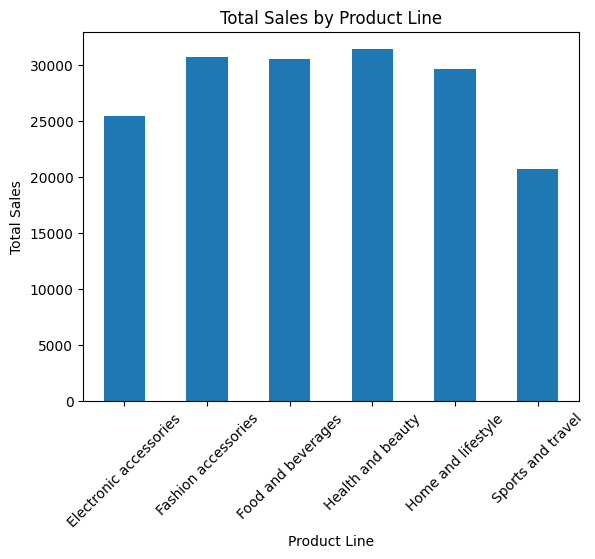

In [77]:
df.groupby('Product_line')['Total'].sum().plot(
    kind='bar',
    title='Total Sales by Product Line'
)

plt.xlabel('Product Line')
plt.ylabel('Total Sales')
plt.xticks(rotation=45)
plt.show()

## Average Unit Price by Product Line

Home and lifestyle has the highest average unit price (about 59.80), while Food and beverages has the lowest (about 53.39).

A higher average unit price does not necessarily mean higher total sales because sales also depend on transaction volume and quantity.


In [78]:
df.groupby('Product_line')['Unit_price'].mean()

,Unit_price
Product_line,
Electronic accessories,54.703878
Fashion accessories,57.465766
Food and beverages,53.385773
Health and beauty,57.831714
Home and lifestyle,59.804706
Sports and travel,55.330690


## Average Quantity by Product Line

Food and beverages has the highest average quantity per transaction (about 5.66).

Electronic accessories has the lowest average quantity (about 4.47).


In [79]:
df.groupby('Product_line')['Quantity'].mean()

,Quantity
Product_line,
Electronic accessories,4.469388
Fashion accessories,5.000000
Food and beverages,5.659794
Health and beauty,4.961905
Home and lifestyle,4.745098
Sports and travel,4.597701


# Key Insights

1. **Data quality:** The original dataset contained 8 duplicate rows and 8 missing values each in Gender, Payment, and Unit_price.
2. **Data cleaning:** Duplicate rows were removed, and missing Unit_price values were reconstructed using `Total / Quantity`.
3. **Product lines:** Health and beauty generated the highest total sales (31,412.33), while Sports and travel generated the lowest (20,718.05).
4. **Transaction size:** Food and beverages had the highest average quantity (5.66) and average transaction total (315.00).
5. **Quantity and sales:** Quantity and Total have a strong positive correlation of about 0.83.
6. **City performance:** Bhopal had the highest total sales (62,904.85) and highest average transaction value (288.55).
7. **Customer type:** Members generated slightly higher total sales, but Normal customers had a higher average transaction value.
8. **Payment methods:** Ewallet had the highest average transaction value, while Credit card had the highest total sales.
9. **Daily pattern:** Day 27 recorded the highest total sales, while day 2 recorded the lowest among the calendar days analyzed.
10. **High quantities:** A small number of transactions had unusually high quantities (above 10), so these values should be investigated rather than automatically removed.

## Conclusion

This project demonstrates a complete beginner-to-intermediate EDA workflow: inspecting the data, identifying quality issues, cleaning the dataset, grouping and aggregating business metrics, measuring relationships, and extracting descriptive insights.

The next step would be to improve the analysis with additional visualizations and deeper time-based analysis, such as monthly sales trends and product-line performance over time.
